# Fase 1: Parseo e Ingesta con Docling

Evalúa la calidad de extracción de Docling en los tres tipos de documentos del proyecto:
- PDFs de normativa (tablas, numeraciones)
- Actas de reunión
- Contratos y subcontratos

In [2]:
import sys
import os
import json
from pathlib import Path

import torch
import pandas as pd
import tiktoken
import psycopg2
import psycopg2.extras
from pypdf import PdfReader
from openai import OpenAI
from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions, ThreadedPdfPipelineOptions
from docling.datamodel.accelerator_options import AcceleratorOptions, AcceleratorDevice
from docling.datamodel.settings import settings
from docling_core.types.doc import PictureItem

sys.path.insert(0, str(Path.cwd().parent))
from src.config import DOCUMENT_TYPES

PROCESSED_DIR = Path.cwd().parent / "data" / "processed_data"

In [17]:
import torch
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA disponible : {torch.cuda.is_available()}")
print(f"CUDA compilado  : {torch.version.cuda}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.6.0+cu124
CUDA disponible : True
CUDA compilado  : 12.4
GPU             : NVIDIA GeForce RTX 2070 SUPER


## 1.1 Inventario de documentos

In [9]:
enc = tiktoken.get_encoding("cl100k_base")

def count_tokens_from_pdf(pdf_path):
    " Contador de tokens para un archivo PDF "
    reader = PdfReader(str(pdf_path))
    text = "".join(page.extract_text() or "" for page in reader.pages)
    return len(enc.encode(text))

print("📂 Documentos disponibles:\n")

all_files = []
total_size_mb = 0
total_tokens = 0

for doc_type, directory in DOCUMENT_TYPES.items():
    if directory.exists():
        for pdf in sorted(directory.glob("*.pdf")):
            size_mb = os.path.getsize(pdf) / (1024 * 1024)
            tokens = count_tokens_from_pdf(pdf)
            total_size_mb += size_mb
            total_tokens += tokens
            all_files.append({
                "Tipo": doc_type,
                "Archivo": pdf.name,
                "Tamaño (MB)": round(size_mb, 2),
                "Tokens": tokens
            })

if all_files:
    df = pd.DataFrame(all_files)
    print(df.to_string(index=False))
    print("\n" + "="*70)
    print(f"📊 TOTALES: {len(all_files)} archivos | {round(total_size_mb, 2)} MB | {total_tokens:,} tokens")
    print("="*70)
else:
    print("⚠️  No hay PDFs. Coloca archivos en: data/raw/{normativa,actas,contratos,proyecto}/")

📂 Documentos disponibles:

     Tipo                                                                                        Archivo  Tamaño (MB)  Tokens
normativa                                                           capitulo_1._principios_generales.pdf         0.17    7099
normativa                             capitulo_17._criterios_generales_para_las_estructuras_de_acero.pdf         0.54    2141
normativa      capitulo_18._propiedades_tecnologicas_de_los_materiales_para_las_estructuras_de_acero.pdf         0.25   14128
normativa                                       capitulo_19._durabilidad_de_las_estructuras_de_acero.pdf         0.20    3133
normativa      capitulo_2._bases_generales_para_la_contribucion_de_la_estructura_a_la_sostenibilidad.pdf         0.09    3615
normativa                         capitulo_20._estructuras_de_acero._dimensionamiento_y_comprobacion.pdf         0.06     192
normativa                             capitulo_21._fabricacion_y_montaje_de_las_estructuras

## 1.2 Extracción con Docling

In [10]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
MIN_IMAGE_PX = 100   # descarta imágenes con ancho O alto <= este valor (iconos)
IMAGES_SCALE = 1.0   # resolución para extracción de figuras

# ── GPU / CPU ─────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    device     = AcceleratorDevice.CUDA
    vram_gb    = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    batch_size = 128 if vram_gb > 40 else 64 if vram_gb > 20 else 16
    print(f"✓ GPU detectada: {torch.cuda.get_device_name(0)} ({vram_gb:.1f} GB VRAM) → batch={batch_size}")
else:
    device     = AcceleratorDevice.CPU
    batch_size = 4
    print("⚠️  GPU no disponible, usando CPU")

# ── Pipeline: do_ocr=False porque los PDFs tienen texto embebido ──────────────
pipeline_options = ThreadedPdfPipelineOptions(
    do_ocr              = False,
    layout_batch_size   = batch_size,
    table_batch_size    = 4,
    accelerator_options = AcceleratorOptions(device=device),
)
pipeline_options.generate_picture_images = True
pipeline_options.images_scale            = IMAGES_SCALE

converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    },
)

settings.perf.doc_batch_concurrency = 4
settings.perf.doc_batch_size        = 4

# ── Recoger PDFs ──────────────────────────────────────────────────────────────
all_pdfs = []
for doc_type, raw_dir in DOCUMENT_TYPES.items():
    if raw_dir.exists():
        for pdf_path in sorted(raw_dir.glob("*.pdf")):
            all_pdfs.append((doc_type, pdf_path))

print(f"\n{len(all_pdfs)} PDFs listos para procesar")

# ── Conversión ────────────────────────────────────────────────────────────────
results_summary = []

for result in converter.convert_all(
    [p for _, p in all_pdfs],
    raises_on_error=False,
):
    source_name = Path(result.input.file).name
    doc_type    = next(dt for dt, p in all_pdfs if p.name == source_name)

    out_dir    = PROCESSED_DIR / doc_type / Path(result.input.file).stem
    images_dir = out_dir / "images"
    out_dir.mkdir(parents=True, exist_ok=True)
    images_dir.mkdir(exist_ok=True)

    if result.document is None:
        print(f"  ✗ {source_name} — {result.status}")
        results_summary.append({"doc_type": doc_type, "archivo": source_name,
                                 "textos": 0, "tablas": 0, "imágenes": 0, "ok": False})
        continue

    doc = result.document

    # ── JSON ──────────────────────────────────────────────────────────────────
    doc_dict = doc.export_to_dict()
    with open(out_dir / "document.json", "w", encoding="utf-8") as f:
        json.dump(doc_dict, f, ensure_ascii=False, indent=2)

    # ── Imágenes — filtra iconos por dimensión ────────────────────────────────
    n_images  = 0
    n_skipped = 0
    for element, _level in doc.iterate_items():
        if isinstance(element, PictureItem):
            img = element.get_image(doc)
            if img is None:
                continue
            w, h = img.size
            if w <= MIN_IMAGE_PX or h <= MIN_IMAGE_PX:
                n_skipped += 1
                continue
            img.save(images_dir / f"picture_{n_images:03d}.png", "PNG")
            n_images += 1

    n_texts  = len(doc_dict.get("texts",  []))
    n_tables = len(doc_dict.get("tables", []))
    skip_str = f" (descartados {n_skipped} iconos)" if n_skipped else ""
    print(f"  ✓ [{doc_type}] {source_name}  →  {n_texts} textos | {n_tables} tablas | {n_images} imágenes{skip_str}")

    results_summary.append({"doc_type": doc_type, "archivo": source_name,
                             "textos": n_texts, "tablas": n_tables, "imágenes": n_images, "ok": True})

# ── Resumen ───────────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
df_summary = pd.DataFrame(results_summary)
print(df_summary.to_string(index=False))
print(f"\n✓ Procesados: {df_summary['ok'].sum()}/{len(df_summary)}")

✓ GPU detectada: NVIDIA GeForce RTX 2070 SUPER (8.0 GB VRAM) → batch=16

28 PDFs listos para procesar


Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

  ✓ [normativa] capitulo_1._principios_generales.pdf  →  128 textos | 0 tablas | 0 imágenes (descartados 9 iconos)
  ✓ [normativa] capitulo_17._criterios_generales_para_las_estructuras_de_acero.pdf  →  23 textos | 2 tablas | 0 imágenes (descartados 5 iconos)
  ✓ [normativa] capitulo_18._propiedades_tecnologicas_de_los_materiales_para_las_estructuras_de_acero.pdf  →  276 textos | 38 tablas | 0 imágenes (descartados 21 iconos)
  ✓ [normativa] capitulo_19._durabilidad_de_las_estructuras_de_acero.pdf  →  81 textos | 0 tablas | 3 imágenes (descartados 8 iconos)
  ✓ [normativa] capitulo_2._bases_generales_para_la_contribucion_de_la_estructura_a_la_sostenibilidad.pdf  →  53 textos | 1 tablas | 0 imágenes (descartados 5 iconos)
  ✓ [normativa] capitulo_20._estructuras_de_acero._dimensionamiento_y_comprobacion.pdf  →  10 textos | 0 tablas | 0 imágenes (descartados 2 iconos)
  ✓ [normativa] capitulo_21._fabricacion_y_montaje_de_las_estructuras_de_acero.pdf  →  557 textos | 8 tablas | 0 imágenes 

Stage preprocess failed for run 28, pages [55]: std::bad_alloc
Stage preprocess failed for run 28, pages [56]: std::bad_alloc
Stage preprocess failed for run 28, pages [57]: std::bad_alloc
Stage preprocess failed for run 28, pages [58]: std::bad_alloc
Stage preprocess failed for run 28, pages [59]: std::bad_alloc
Stage preprocess failed for run 28, pages [60]: std::bad_alloc
Stage preprocess failed for run 28, pages [61]: std::bad_alloc
Stage preprocess failed for run 28, pages [62]: std::bad_alloc
Stage preprocess failed for run 28, pages [63]: std::bad_alloc
Stage preprocess failed for run 28, pages [64]: std::bad_alloc
Stage preprocess failed for run 28, pages [65]: std::bad_alloc
Stage preprocess failed for run 28, pages [66]: std::bad_alloc
Stage preprocess failed for run 28, pages [67]: std::bad_alloc
Stage preprocess failed for run 28, pages [68]: std::bad_alloc
Stage preprocess failed for run 28, pages [69]: std::bad_alloc
Stage preprocess failed for run 28, pages [70]: std::ba

  ✓ [proyecto] TFG-I-1343.pdf  →  484 textos | 31 tablas | 19 imágenes (descartados 10 iconos)

 doc_type                                                                                        archivo  textos  tablas  imágenes   ok
normativa                                                           capitulo_1._principios_generales.pdf     128       0         0 True
normativa                             capitulo_17._criterios_generales_para_las_estructuras_de_acero.pdf      23       2         0 True
normativa      capitulo_18._propiedades_tecnologicas_de_los_materiales_para_las_estructuras_de_acero.pdf     276      38         0 True
normativa                                       capitulo_19._durabilidad_de_las_estructuras_de_acero.pdf      81       0         3 True
normativa      capitulo_2._bases_generales_para_la_contribucion_de_la_estructura_a_la_sostenibilidad.pdf      53       1         0 True
normativa                         capitulo_20._estructuras_de_acero._dimensionamiento_y_

## 1.3 Inspección de un documento extraído

Muestra estadísticas del JSON y, si el documento tiene imágenes, las renderiza con la bounding-box de Docling superpuesta sobre la página PDF.

📄 Documento : capitulo_6._bases_generales_para_la_gestion_de_las_estructuras_durante_la_fase_de_servicio
Claves JSON  : ['schema_name', 'version', 'name', 'origin', 'furniture', 'body', 'groups', 'texts', 'pictures', 'tables', 'key_value_items', 'form_items', 'pages']

Fragmentos de texto : 155
Tablas              : 1
Imágenes (JSON)     : 9

── Primeros 5 fragmentos ──
  [section_header] Capítulo 6
  [text] Bases generales para la gestión de las estructuras durante su fase de servicio
  [page_footer] 80
  [section_header] Criterios generales para el mantenimiento de las estructuras
  [section_header] Definición de mantenimiento

Imágenes guardadas en disco : 1

── Imágenes con bounding-box (PDF: capitulo_6._bases_generales_para_la_gestion_de_las_estructuras_durante_la_fase_de_servicio.pdf) ──

  Imagen 0 — página 6  |  bbox l=114 t=468 r=473 b=138


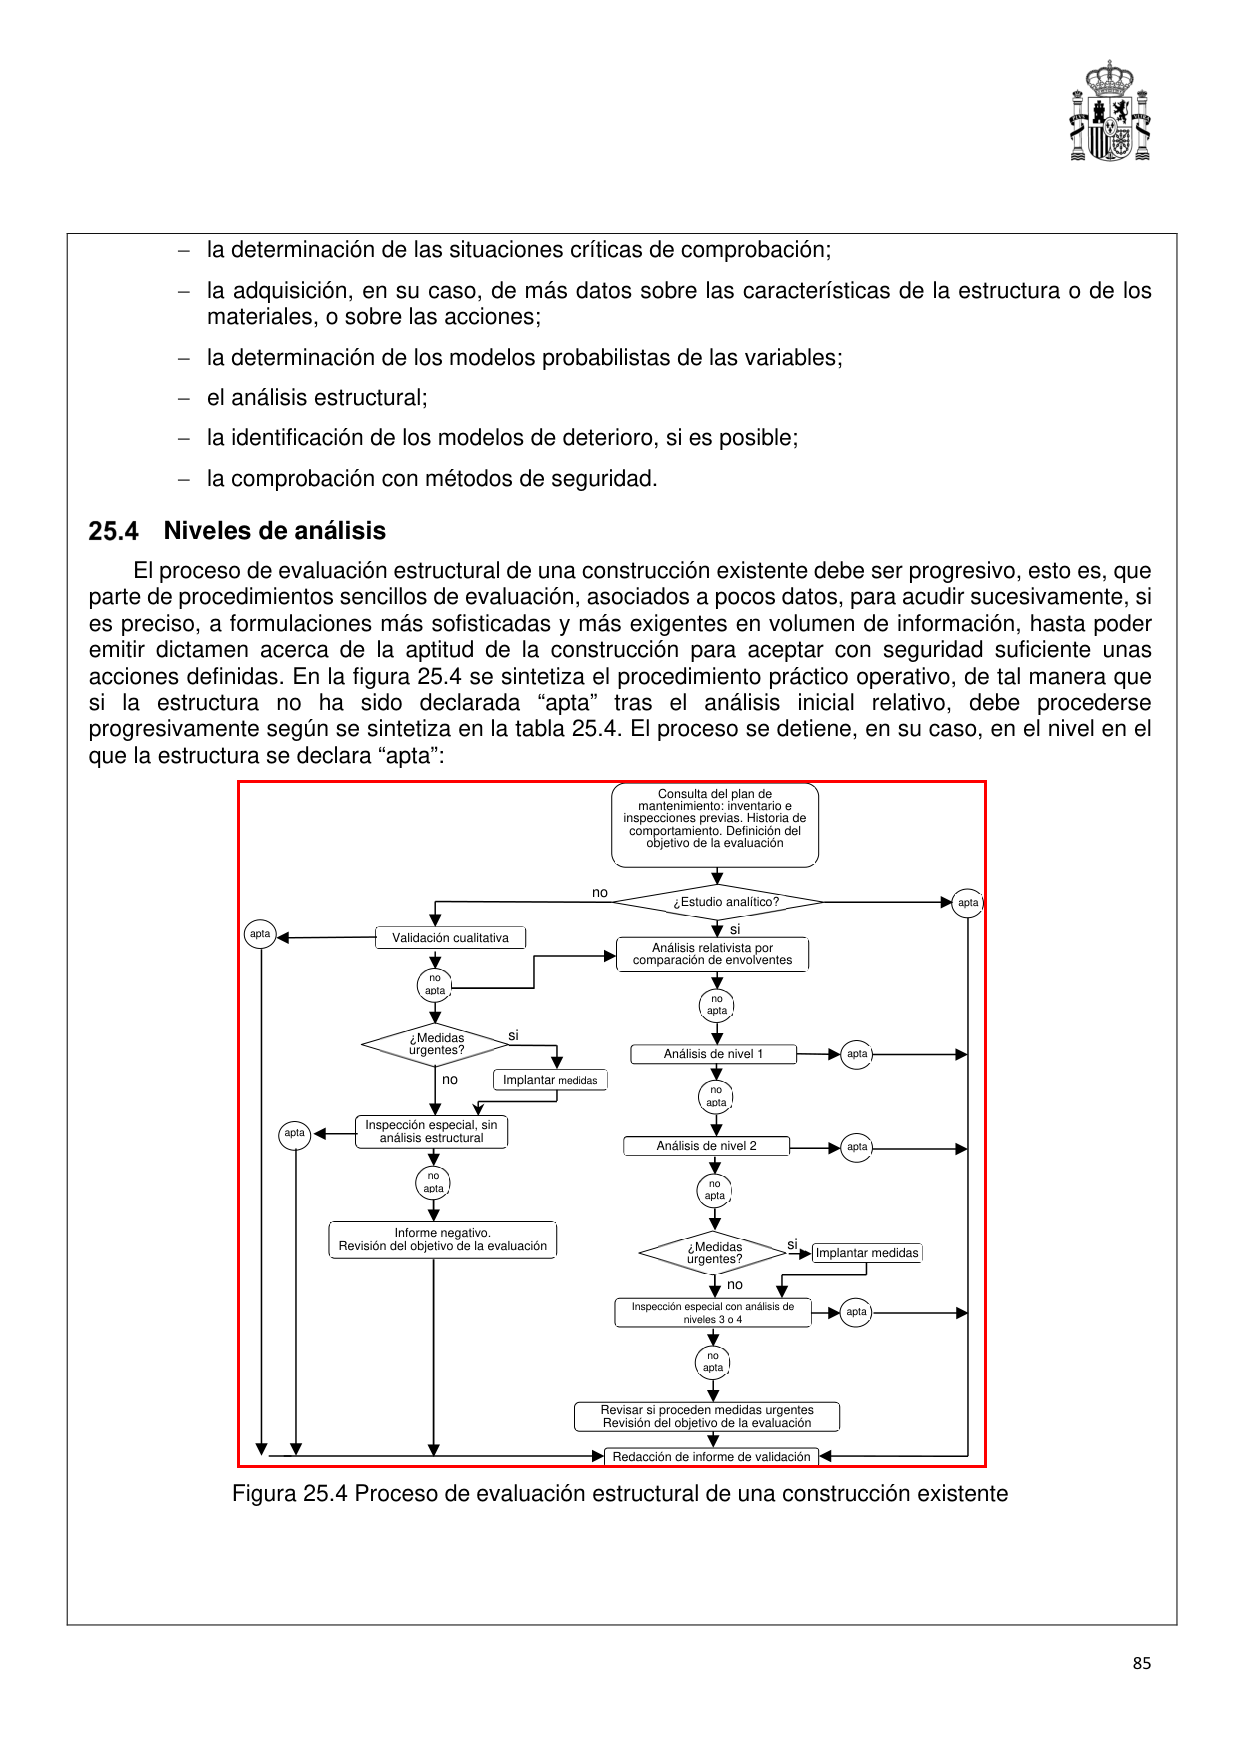

In [22]:
import fitz
from PIL import Image, ImageDraw
from IPython.display import display, Image as IPImage
import io

# ── CONFIG ────────────────────────────────────────────────────────────────────
INSPECT_TYPE = "normativa"
INSPECT_STEM = "capitulo_6._bases_generales_para_la_gestion_de_las_estructuras_durante_la_fase_de_servicio"
# None = primer documento del tipo

# ── Localizar documento ────────────────────────────────────────────────────────
type_dir = PROCESSED_DIR / INSPECT_TYPE
inspect_dirs = sorted(type_dir.iterdir()) if type_dir.exists() else []

if not inspect_dirs:
    print("⚠️  No hay documentos procesados. Ejecuta la celda de extracción primero.")
else:
    target = next((d for d in inspect_dirs if INSPECT_STEM and d.name == INSPECT_STEM), inspect_dirs[0])
    json_path = target / "document.json"

    with open(json_path, encoding="utf-8") as f:
        doc_json = json.load(f)

    print(f"📄 Documento : {target.name}")
    print(f"Claves JSON  : {list(doc_json.keys())}\n")

    texts  = doc_json.get("texts",    [])
    tables = doc_json.get("tables",   [])
    pics   = doc_json.get("pictures", [])
    print(f"Fragmentos de texto : {len(texts)}")
    print(f"Tablas              : {len(tables)}")
    print(f"Imágenes (JSON)     : {len(pics)}")

    print(f"\n── Primeros 5 fragmentos ──")
    for t in texts[:5]:
        print(f"  [{t.get('label','?')}] {t.get('text','')[:120]}")

    saved_imgs = sorted((target / "images").glob("*.png"))
    print(f"\nImágenes guardadas en disco : {len(saved_imgs)}")

    # ── Buscar PDF original ────────────────────────────────────────────────────
    raw_pdf = None
    for doc_type, raw_dir in DOCUMENT_TYPES.items():
        candidate = raw_dir / (target.name + ".pdf")
        if candidate.exists():
            raw_pdf = candidate
            break

    # ── Filtrar pictures reales (> MIN_IMAGE_PX en ambas dimensiones) ──────────
    real_pics = [
        p for p in pics
        if p.get("image", {}).get("size", {}).get("width",  0) > MIN_IMAGE_PX
        and p.get("image", {}).get("size", {}).get("height", 0) > MIN_IMAGE_PX
        and p.get("prov")
    ]

    if not real_pics:
        print("\n(sin imágenes significativas para mostrar)")
    elif raw_pdf is None:
        print("\n⚠️  PDF original no encontrado; mostrando imágenes recortadas:")
        for img_path in saved_imgs:
            print(f"\n  {img_path.name}")
            display(IPImage(filename=str(img_path), width=400))
    else:
        pdf_doc = fitz.open(str(raw_pdf))
        pages   = doc_json.get("pages", {})

        print(f"\n── Imágenes con bounding-box (PDF: {raw_pdf.name}) ──")
        for idx, pic in enumerate(real_pics):
            prov     = pic["prov"][0]
            page_no  = prov["page_no"]
            bbox_doc = prov["bbox"]           # coord_origin = BOTTOMLEFT

            page_info = pages.get(str(page_no), {})
            page_h    = page_info.get("size", {}).get("height", 842)
            page_w    = page_info.get("size", {}).get("width",  595)

            # Convertir BOTTOMLEFT → TOPLEFT invirtiendo Y
            l = bbox_doc["l"]
            r = bbox_doc["r"]
            t = page_h - bbox_doc["t"]
            b = page_h - bbox_doc["b"]

            # Render página a 150 dpi
            page = pdf_doc[page_no - 1]
            mat  = fitz.Matrix(150 / 72, 150 / 72)
            pix  = page.get_pixmap(matrix=mat)
            img  = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)

            scale_x = pix.width  / page_w
            scale_y = pix.height / page_h

            draw = ImageDraw.Draw(img)
            draw.rectangle(
                [l * scale_x, t * scale_y, r * scale_x, b * scale_y],
                outline="red", width=3
            )

            buf = io.BytesIO()
            img.save(buf, format="PNG")
            buf.seek(0)

            caption = pic.get("captions", [])
            cap_txt = caption[0].get("text", "") if caption else ""
            print(f"\n  Imagen {idx} — página {page_no}  |  bbox l={l:.0f} t={bbox_doc['t']:.0f} r={r:.0f} b={bbox_doc['b']:.0f}")
            if cap_txt:
                print(f"  Caption: {cap_txt[:120]}")
            display(IPImage(data=buf.read(), width=600))

        pdf_doc.close()

## 1.4 Generación de embeddings e ingesta en pgvector

In [3]:
import os
from dotenv import load_dotenv
load_dotenv(Path.cwd().parent / ".env")

# ── CONFIG ────────────────────────────────────────────────────────────────────
DB_HOST          = "localhost"
DB_PORT          = 5433
DB_NAME          = "maic"
DB_USER          = "postgres"
DB_PASSWORD      = os.getenv("POSTGRES_PASSWORD", "postgres")
OPENAI_API_KEY   = os.getenv("OPENAI_API_KEY")
EMBEDDING_MODEL  = "text-embedding-3-small"
EMBEDDING_DIM    = 1536
EMBED_BATCH_SIZE = 100
SKIP_LABELS      = {"page_footer", "page_header", "picture"}

# ── Cargar chunks desde los JSON procesados ───────────────────────────────────
client = OpenAI(api_key=OPENAI_API_KEY)

chunks = []
for doc_type_dir in sorted(PROCESSED_DIR.iterdir()):
    if not doc_type_dir.is_dir():
        continue
    doc_type = doc_type_dir.name
    for doc_dir in sorted(doc_type_dir.iterdir()):
        json_path = doc_dir / "document.json"
        if not json_path.exists():
            continue
        with open(json_path, encoding="utf-8") as f:
            doc_json = json.load(f)
        source = doc_dir.name
        for item in doc_json.get("texts", []):
            label   = item.get("label", "")
            content = item.get("text",  "").strip()
            if label in SKIP_LABELS or not content:
                continue
            page_no = item["prov"][0]["page_no"] if item.get("prov") else None
            chunks.append({
                "doc_type": doc_type,
                "source":   source,
                "page_no":  page_no,
                "label":    label,
                "content":  content,
            })

print(f"Chunks cargados: {len(chunks)}")
print(f"Ejemplo: [{chunks[0]['label']}] {chunks[0]['content'][:100]}")

# ── Generar embeddings en batches ─────────────────────────────────────────────
print(f"\nGenerando embeddings con {EMBEDDING_MODEL}...")
embeddings = []
for i in range(0, len(chunks), EMBED_BATCH_SIZE):
    batch   = chunks[i : i + EMBED_BATCH_SIZE]
    texts   = [c["content"] for c in batch]
    resp    = client.embeddings.create(model=EMBEDDING_MODEL, input=texts)
    embeddings.extend([r.embedding for r in resp.data])
    print(f"  {min(i + EMBED_BATCH_SIZE, len(chunks))}/{len(chunks)}", end="\r")

print(f"\n✓ {len(embeddings)} embeddings generados (dim={len(embeddings[0])})")

Chunks cargados: 2793
Ejemplo: [section_header] Acta 1 - Inicio y movimiento de tierras

Generando embeddings con text-embedding-3-small...
  2793/2793
✓ 2793 embeddings generados (dim=1536)


In [4]:
# ── Insertar en pgvector ──────────────────────────────────────────────────────
conn = psycopg2.connect(
    host=DB_HOST, port=DB_PORT, dbname=DB_NAME,
    user=DB_USER, password=DB_PASSWORD
)

INSERT_SQL = """
    INSERT INTO documents (doc_type, source, page_no, label, content, embedding)
    VALUES %s
"""

rows = [
    (c["doc_type"], c["source"], c["page_no"], c["label"], c["content"], emb)
    for c, emb in zip(chunks, embeddings)
]

with conn:
    with conn.cursor() as cur:
        cur.execute("TRUNCATE TABLE documents RESTART IDENTITY")
        psycopg2.extras.execute_values(cur, INSERT_SQL, rows, page_size=200)

conn.close()

# ── Verificar ─────────────────────────────────────────────────────────────────
conn = psycopg2.connect(
    host=DB_HOST, port=DB_PORT, dbname=DB_NAME,
    user=DB_USER, password=DB_PASSWORD
)
with conn.cursor() as cur:
    cur.execute("SELECT doc_type, COUNT(*) FROM documents GROUP BY doc_type ORDER BY doc_type")
    rows_db = cur.fetchall()
conn.close()

print(f"{'='*50}")
print(f"{'doc_type':<20} {'chunks':>8}")
print(f"{'='*50}")
total = 0
for doc_type, count in rows_db:
    print(f"{doc_type:<20} {count:>8}")
    total += count
print(f"{'─'*50}")
print(f"{'TOTAL':<20} {total:>8}")
print(f"{'='*50}")

doc_type               chunks
actas                     294
contratos                 161
normativa                1949
proyecto                  389
──────────────────────────────────────────────────
TOTAL                    2793
